In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix
from sklearn.utils import shuffle

In [2]:
# Load dataset
df = pd.read_csv('/datasets/Churn.csv')

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

print("\nData types and non-null counts:")
print(df.info())

print("\nDescriptive statistics:")
display(df.describe())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (10000, 14)

Column names:
 ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

First 5 rows:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0



Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB
None

Descriptive statistics:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,9091.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,4.997690,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.894723,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,2.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000



Missing values per column:
RowNumber            0
CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure             909
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64

Duplicate rows: 0


### Analysis 
The first review shows that some columns are useful for prediction, while others are only identifiers. RowNumber, CustomerId, and Surname do not describe customer behavior, so they should not be used for model training. The descriptive statistics also show that the data includes both numerical features, such as CreditScore, Age, Balance, and EstimatedSalary, and categorical features, such as Geography and Gender.

Tenure missing values: 909
count    9091.000000
mean        4.997690
std         2.894723
min         0.000000
25%         2.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: Tenure, dtype: float64


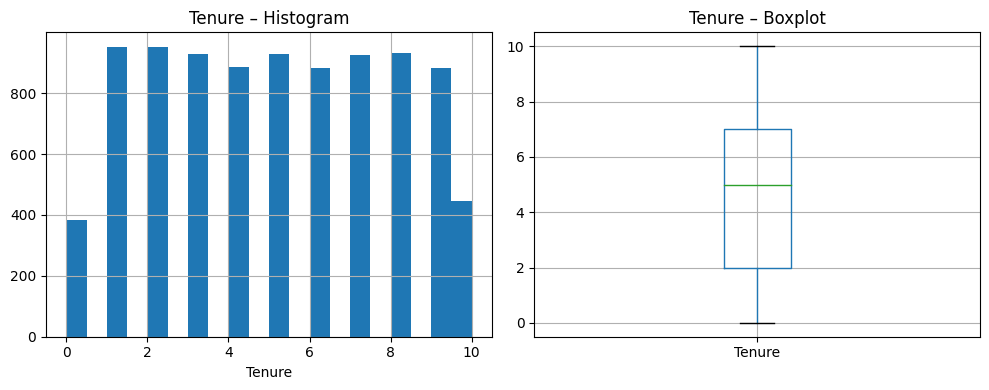

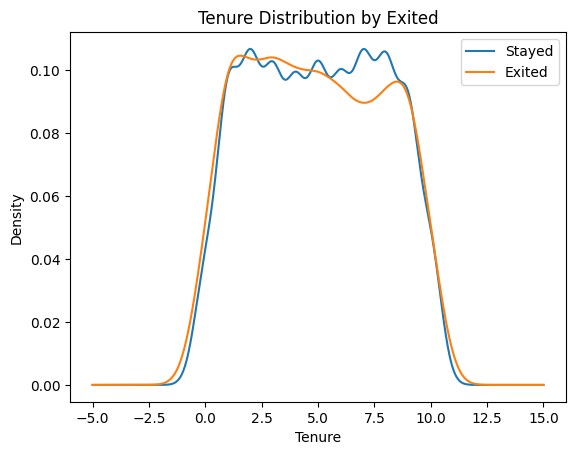

Missing values after imputation:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
['France' 'Spain' 'Germany']


In [ ]:
# Remove uninformative columns
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print("Tenure missing values:", df['Tenure'].isnull().sum())
print(df['Tenure'].describe())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['Tenure'].hist(bins=20, ax=axes[0])
axes[0].set_title('Tenure – Histogram')
axes[0].set_xlabel('Tenure')

df.boxplot(column='Tenure', ax=axes[1])
axes[1].set_title('Tenure – Boxplot')
plt.tight_layout()
plt.show()


df[df['Exited'] == 0]['Tenure'].plot(kind='kde', label='Stayed', ax=plt.gca())
df[df['Exited'] == 1]['Tenure'].plot(kind='kde', label='Exited', ax=plt.gca())
plt.title('Tenure Distribution by Exited')
plt.xlabel('Tenure')
plt.legend()
plt.show()

# fill null values with median
df['Tenure'] = df['Tenure'].fillna(df['Tenure'].median())
print("Missing values after imputation:")
print(df.isnull().sum())


df_unique = df['Geography'].unique()
print(df_unique)

### Analysis
In this section, the uninformative columns RowNumber, CustomerId, and Surname are removed because they do not provide meaningful business value for predicting churn. The missing values in Tenure are filled with the median value. Before imputing, a histogram, boxplot, and KDE plot split by the Exited class are used to confirm the distribution shape and check for outliers. This is a reasonable choice because it keeps all customer records in the dataset without letting extreme values affect the replacement value. After imputation, the output confirms that there are no missing values left.

In [4]:
# encode data
df = pd.get_dummies(df, columns=['Geography'], drop_first=False)

encoder = OrdinalEncoder(categories=[['Female', 'Male']])
df['Gender'] = encoder.fit_transform(df[['Gender']])


print("\nFeature list after encoding:")
print(df.columns.tolist())
print(df.head(5))


Feature list after encoding:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France', 'Geography_Germany', 'Geography_Spain']
   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619     0.0   42     2.0       0.00              1          1   
1          608     0.0   41     1.0   83807.86              1          0   
2          502     0.0   42     8.0  159660.80              3          1   
3          699     0.0   39     1.0       0.00              2          0   
4          850     0.0   43     2.0  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_France  \
0               1        101348.88       1                 1   
1               1        112542.58       0                 0   
2               0        113931.57       1                 1   
3               0         93826.63       0                 1   
4 

### Analysis
This section converts categorical variables into numeric form so the models can process them. Geography is converted into separate dummy columns for France, Germany, and Spain. Gender is encoded as a numeric variable using ordinal encoding. After encoding, the output confirms that all features are now numeric and ready for model training.

In [ ]:
# split test data
target = df['Exited']
features = df.drop('Exited', axis=1)

features_train, x_temp, target_train, y_temp = train_test_split(
    features, target, test_size=.4, random_state=12345, stratify=target)

features_valid, features_test, target_valid, target_test = train_test_split(
    x_temp, y_temp, test_size=.5, random_state=12345, stratify=y_temp)

### Analysis
The data is split into three sets: training, validation, and test. The training set is used to fit the models, the validation set is used to compare model performance and tune the approach, and the test set is saved for the final evaluation. The split creates a 60% training set, 20% validation set, and 20% test set. Stratify is applied to both splits so that the class proportions are preserved across all three sets. This follows the project requirement because the final test set is not used until the final model evaluation.

In [ ]:
# feature scaling
scaler = StandardScaler()

features_train_scaled = scaler.fit_transform(features_train)
features_valid_scaled = scaler.transform(features_valid)
features_test_scaled = scaler.transform(features_test)

features_train_scaled = pd.DataFrame(
    features_train_scaled, columns=features.columns)
features_valid_scaled = pd.DataFrame(
    features_valid_scaled, columns=features.columns)
features_test_scaled = pd.DataFrame(
    features_test_scaled, columns=features.columns)

print(features_train_scaled.head())

   CreditScore    Gender       Age    Tenure   Balance  NumOfProducts  \
0    -1.040434 -1.102198  0.953312  0.360600  0.774657      -0.914708   
1     0.454006 -1.102198 -0.095244 -0.002786  1.910540      -0.914708   
2     0.103585  0.907278 -0.476537  1.087371  0.481608       0.820981   
3    -0.184996 -1.102198  0.190726 -0.002786  0.088439      -0.914708   
4    -0.720933 -1.102198  1.620574 -1.456328  0.879129      -0.914708   

   HasCrCard  IsActiveMember  EstimatedSalary  Geography_France  \
0  -1.525709        0.969466        -0.119110         -1.005013   
1   0.655433        0.969466        -0.258658          0.995012   
2  -1.525709        0.969466         1.422836          0.995012   
3   0.655433        0.969466        -1.160427         -1.005013   
4   0.655433       -1.031496         0.113236          0.995012   

   Geography_Germany  Geography_Spain  
0           1.739007        -0.575811  
1          -0.575041        -0.575811  
2          -0.575041        -0.575811 

### Analysis
StandardScaler is applied to the features after the train-validation-test split. This is important because numerical columns have very different scales, such as Balance, EstimatedSalary, Age, and CreditScore. Scaling helps models like Logistic Regression perform better because the model is not overly influenced by larger-numbered features. The scaler is fit only on the training data and then applied to validation and test data, which prevents data leakage. The output shows the scaled training features, where values are centered around a standard scale.

In [7]:
# mbalance investigation
print(target_train.value_counts())
print(target_train.value_counts(normalize=True).round(3))

0    4778
1    1222
Name: Exited, dtype: int64
0    0.796
1    0.204
Name: Exited, dtype: float64


### Analysis
The training target shows that 4,778 customers did not leave and 1,222 customers did leave. This means about 79.6% of the training data is class 0 and 20.4% is class 1. The imbalance ratio is about 4:1. This is important because the model may become better at predicting customers who stay, while missing customers who actually leave. Since the business goal is to identify churned customers, this imbalance needs to be addressed.

In [ ]:
# model without imbalance handling

# Logistic Regression
print('Logistic Regression')
baseline_lr = LogisticRegression(max_iter=1000, random_state=12345)
baseline_lr.fit(features_train_scaled, target_train)

predicted_valid = baseline_lr.predict(features_valid_scaled)
print('F1:', f1_score(target_valid, predicted_valid))
print('AUC-ROC:', roc_auc_score(target_valid,
      baseline_lr.predict_proba(features_valid_scaled)[:, 1]))

# Random Forest
print('Random Forest')
baseline_rf = RandomForestClassifier(random_state=12345)
baseline_rf.fit(features_train_scaled, target_train)

predicted_valid = baseline_rf.predict(features_valid_scaled)
print('F1:', f1_score(target_valid, predicted_valid))
print('AUC-ROC:', roc_auc_score(target_valid,
      baseline_rf.predict_proba(features_valid_scaled)[:, 1]))

# Decision Tree
print('Decision Tree')
baseline_dt = DecisionTreeClassifier(random_state=12345)
baseline_dt.fit(features_train_scaled, target_train)

predicted_valid = baseline_dt.predict(features_valid_scaled)
print('F1:', f1_score(target_valid, predicted_valid))
print('AUC-ROC:', roc_auc_score(target_valid,
      baseline_dt.predict_proba(features_valid_scaled)[:, 1]))

Logistic Regression
F1: 0.3107861060329068
AUC-ROC: 0.7874590476894274
Random Forest
F1: 0.6
AUC-ROC: 0.860924567691398
Decision Tree
F1: 0.49767441860465117
AUC-ROC: 0.6875061582421913


### Analysis
This section trains Logistic Regression, Random Forest, and Decision Tree models without correcting the class imbalance. The results show that Logistic Regression has a low F1 score of 0.3108, meaning it struggles to correctly identify churned customers. The baseline Random Forest performs best with an F1 score of 0.6 and AUC-ROC of 0.8609, but the F1 score is still above the project requirement of 0.59. The Decision Tree has an F1 score of 0.4977 and AUC-ROC of 0.6875. Overall, the results show that imbalance handling is needed to improve performance.

In [ ]:
# balanced weight models

# Random Forest
print('Random Forest')
rf = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=12345
)
rf.fit(features_train_scaled, target_train)

predicted_valid = rf.predict(features_valid_scaled)
print('F1:', f1_score(target_valid, predicted_valid))
print('AUC-ROC:', roc_auc_score(target_valid,
      rf.predict_proba(features_valid_scaled)[:, 1]))

# Logistic Regression
print('Logistic Regression')
lr = LogisticRegression(
    class_weight='balanced',
    C=0.1,
    solver='liblinear',
    max_iter=1000,
    random_state=12345
)
lr.fit(features_train_scaled, target_train)

predicted_valid = lr.predict(features_valid_scaled)
print('F1:', f1_score(target_valid, predicted_valid))
print('AUC-ROC:', roc_auc_score(target_valid,
      lr.predict_proba(features_valid_scaled)[:, 1]))

# Decision Tree
print('Decision Tree')
dt = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=12345
)
dt.fit(features_train_scaled, target_train)

predicted_valid = dt.predict(features_valid_scaled)
print('F1:', f1_score(target_valid, predicted_valid))
print('AUC-ROC:', roc_auc_score(target_valid,
      dt.predict_proba(features_valid_scaled)[:, 1]))

Random Forest
F1: 0.6462264150943396
AUC-ROC: 0.8728954207311065
Logistic Regression
F1: 0.5280701754385966
AUC-ROC: 0.7936804118632378
Decision Tree
F1: 0.5449688334817453
AUC-ROC: 0.800412140358656


### Analysis
This section improves the models by using class_weight='balanced'. This tells the model to give more importance to the minority class, which is customers who exited. The Random Forest model performs best in this section with an F1 score of 0.6462 and AUC-ROC of 0.8729. Logistic Regression improves compared to its baseline but still has a lower F1 score of 0.5281. The Decision Tree reaches an F1 score of 0.5450. The results show that class weighting helps the model focus more on churned customers and improves the overall F1 score.

In [ ]:
# Upsampled function

def upsample(features, target, repeat):
    features = features.reset_index(drop=True)
    target = target.reset_index(drop=True)

    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]
    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)
    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345
    )
    return features_upsampled, target_upsampled


features_train_up, target_train_up = upsample(
    features_train_scaled, target_train, 10)

### Analysis
The upsampling function increases the number of minority-class observations in the training data. It separates customers who stayed from customers who exited, repeats the churned customer records, combines the data back together, and shuffles the result. This gives the model more examples of customers who left the bank. No output is shown here because the function creates the upsampled training data but does not print the new class distribution.

In [ ]:
# Upsampled model

# Logistic Regression
print('Logistic Regression')
up_lr = LogisticRegression(
    C=0.1,
    solver='liblinear',
    max_iter=1000,
    random_state=12345
)
up_lr.fit(features_train_up, target_train_up)

predicted_valid = up_lr.predict(features_valid_scaled)
print('F1:', f1_score(target_valid, predicted_valid))
print('AUC-ROC:', roc_auc_score(target_valid,
      up_lr.predict_proba(features_valid_scaled)[:, 1]))

# Random Forest
print('Random Forest')
up_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=12345
)
up_rf.fit(features_train_up, target_train_up)

predicted_valid = up_rf.predict(features_valid_scaled)
print('F1:', f1_score(target_valid, predicted_valid))
print('AUC-ROC:', roc_auc_score(target_valid,
      up_rf.predict_proba(features_valid_scaled)[:, 1]))

# Decision Tree
print('Decision Tree')
up_dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=12345
)
up_dt.fit(features_train_up, target_train_up)

predicted_valid = up_dt.predict(features_valid_scaled)
print('F1:', f1_score(target_valid, predicted_valid))
print('AUC-ROC:', roc_auc_score(target_valid,
      up_dt.predict_proba(features_valid_scaled)[:, 1]))

Logistic Regression
F1: 0.4190371991247264
AUC-ROC: 0.7958527317962362
Random Forest
F1: 0.5702479338842976
AUC-ROC: 0.8626527244063454
Decision Tree
F1: 0.5091441111923921
AUC-ROC: 0.8244031123756036


### Analysis
This section trains the same three models using the upsampled training data. Logistic Regression produces an F1 score of 0.4190 and AUC-ROC of 0.7959. Random Forest performs best in this section with an F1 score of 0.5703 and AUC-ROC of 0.8627. Decision Tree produces an F1 score of 0.5091 and AUC-ROC of 0.8244. Although upsampling helps test another imbalance strategy, it does not outperform the balanced Random Forest model from the previous section.


In [ ]:
# Best model Random Forest test dataset
best_model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=12345
)
best_model.fit(features_train_scaled, target_train)

predicted_test = best_model.predict(features_test_scaled)
prob_test = best_model.predict_proba(features_test_scaled)[:, 1]
print('Random Forest')
print('F1:', f1_score(target_test, predicted_test))
print('AUC-ROC:', roc_auc_score(target_test, prob_test))

Random Forest
F1: 0.5987878787878788
AUC-ROC: 0.8555489233455335


### Analysis
The best model is the Random Forest model with class_weight='balanced', 300 estimators, max depth of 10, minimum samples split of 5, and minimum samples leaf of 2. This model is trained on the scaled training set and evaluated on the test set. The final test F1 score is 0.5988, which passes the project requirement of at least 0.59. The AUC-ROC score is 0.8556, showing that the model is also strong at ranking customers by churn risk.

### Conclusion
The data was prepared by removing identifier columns that did not help with prediction, filling missing Tenure values with the median, encoding categorical variables, splitting the data into training, validation, and test sets, and scaling the features. These steps made the dataset clean, numeric, and ready for model training.

The class balance check showed that only about 20.4% of customers in the training set exited, while 79.6% stayed. This imbalance affected the baseline models because they were more likely to predict the majority class. The baseline Random Forest performed best without imbalance handling, but its validation F1 score of 0.6 was still above the project requirement.

Two imbalance-handling techniques were tested: class weighting and upsampling. The best validation result came from the Random Forest model with class_weight='balanced', which achieved an F1 score of 0.6462 and an AUC-ROC score of 0.8729. Upsampling was also tested, but it did not perform as well as the balanced Random Forest model.



The final model was tested on the test dataset and achieved an F1 score of 0.5988 and an AUC-ROC score of 0.8556. This meets the project requirement because the test F1 score is above 0.59.

From a business perspective, identifying customers who are likely to leave is valuable because it is cheaper for Beta Bank to retain existing customers than to attract new ones. Higher recall for class 1 is especially important because missing a churned customer means the bank may lose the chance to take action. However, precision also matters because too many false positives could cause the bank to spend retention resources on customers who were not actually likely to leave. The best model should balance these trade-offs while still identifying enough high-risk customers to support the bank’s retention strategy.